In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import geopandas as gpd
    import rasterio
    from rasterio.mask import mask
    from shapely.geometry import mapping
    GEO_STACK_AVAILABLE = True
except ImportError as exc:
    GEO_STACK_AVAILABLE = False
    GEO_IMPORT_ERROR = exc

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("..")

ISRO_DIR = PROJECT_ROOT / "data" / "india ndvi dataset(isro)"
ISRO_RASTER = ISRO_DIR / "ocm2_ndvi_nov16to302021_v02_01.tif"
LABELS_PATH = PROJECT_ROOT / "data" / "SIH1379_ML_Training_Dataset.csv"
LINES_PATH = PROJECT_ROOT / "data" / "GatiShakti_Transmission_Lines_220kV_plus.geojson"
OUTPUT_DIR = PROJECT_ROOT / "notebook" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"ISRO raster: {ISRO_RASTER}")
print(f"Geospatial stack available: {GEO_STACK_AVAILABLE}")

Project root: C:\Users\snghs\Desktop\SIH
ISRO raster: ..\data\india ndvi dataset(isro)\ocm2_ndvi_nov16to302021_v02_01.tif
Geospatial stack available: True


In [6]:
# 2. Inspect the supplied project labels.
labels = pd.read_csv(LABELS_PATH)
feature_candidates = [
    "DistanceToLine", "NDVI", "ProximityFactor", "Vegetation", "VegetationFactor"
]
missing_features = [column for column in feature_candidates if column not in labels.columns]
if missing_features:
    raise ValueError(f"Training data is missing required features: {missing_features}")

labels = labels.dropna(subset=feature_candidates + ["RiskLabel"]).copy()
labels["RiskLabel"] = labels["RiskLabel"].astype(int)
print(f"Training observations: {len(labels):,}")
display(labels[feature_candidates + ["RiskLabel", "RiskScore"]].describe(include="all"))
class_counts = labels["RiskLabel"].value_counts().sort_index()
display(class_counts.rename("count").to_frame())

if class_counts.min() < 10:
    warnings.warn(
        "At least one risk class has fewer than 10 observations. Metrics may be unstable; "
        "this model is for prioritization research, not autonomous safety decisions.",
        RuntimeWarning,
    )

warnings.warn(
    "The supplied RiskLabel values are inspection/heuristic labels, not outage or conductor-contact ground truth.",
    UserWarning,
)

if labels["NDVI"].min() < -1 or labels["NDVI"].max() > 1:
    warnings.warn("Training NDVI values fall outside [-1, 1]; verify scaling before interpretation.", RuntimeWarning)

X = labels[feature_candidates]
y = labels["RiskLabel"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

numeric_features = feature_candidates
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ],
    remainder="drop",
)
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)
print("Model fitted with class-balanced logistic regression.")

Training observations: 1,659


,DistanceToLine,NDVI,ProximityFactor,Vegetation,VegetationFactor,RiskLabel,RiskScore
count,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000
mean,1547.918085,0.428712,0.509456,0.926462,0.192870,0.371308,0.319505
std,909.872434,0.103461,0.222444,0.261097,0.122394,0.489500,0.116187
min,0.000000,-0.337484,0.171923,0.000000,0.000000,0.000000,0.074174
25%,787.051177,0.374049,0.329251,1.000000,0.105785,0.000000,0.234142
50%,1541.849539,0.430268,0.462585,1.000000,0.186097,0.000000,0.306127
75%,2221.868583,0.485671,0.674674,1.000000,0.265245,1.000000,0.397913
max,3521.420168,0.761647,1.000000,1.000000,0.659496,2.000000,0.702645


,count
RiskLabel,
0,1048
1,606
2,5


C:\Users\snghs\AppData\Local\Temp\ipykernel_23116\956023895.py:18: RuntimeWarning: At least one risk class has fewer than 10 observations. Metrics may be unstable; this model is for prioritization research, not autonomous safety decisions.
  warnings.warn(
C:\Users\snghs\AppData\Local\Temp\ipykernel_23116\956023895.py:24: UserWarning: The supplied RiskLabel values are inspection/heuristic labels, not outage or conductor-contact ground truth.
  warnings.warn(


Model fitted with class-balanced logistic regression.


Balanced accuracy: 0.981
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       262
           1       0.96      0.97      0.96       152
           2       0.20      1.00      0.33         1

    accuracy                           0.97       415
   macro avg       0.72      0.98      0.76       415
weighted avg       0.98      0.97      0.98       415



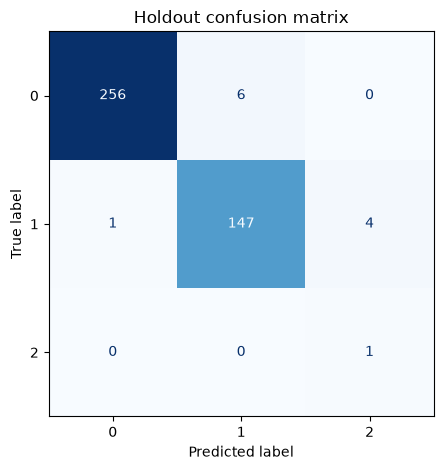

,feature,mean_importance,std
2,ProximityFactor,0.478333,0.098330
4,VegetationFactor,0.471647,0.010532
1,NDVI,0.334137,0.003371
0,DistanceToLine,0.226426,0.165508
3,Vegetation,0.001944,0.001461


Saved showcase model artifact: ..\notebook\outputs\isro_ndvi_transmission_safety_model.joblib


In [7]:
# 3. Evaluate the model with metrics that remain informative under class imbalance.
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)
class_order = list(model.classes_)
high_risk_label = int(labels["RiskLabel"].max())

print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
if len(class_order) == 2 and high_risk_label in class_order:
    print(f"ROC-AUC for high-risk class {high_risk_label}: {roc_auc_score(y_test, y_probability[:, class_order.index(high_risk_label)]):.3f}")
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=False)
plt.title("Holdout confusion matrix")
plt.tight_layout()
plt.show()

importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="balanced_accuracy"
)
importance_table = pd.DataFrame({
    "feature": feature_candidates,
    "mean_importance": importance.importances_mean,
    "std": importance.importances_std,
}).sort_values("mean_importance", ascending=False)
display(importance_table)

import joblib
artifact_path = OUTPUT_DIR / "isro_ndvi_transmission_safety_model.joblib"
joblib.dump({
    "model": model,
    "features": feature_candidates,
    "target": "RiskLabel",
    "high_risk_label": high_risk_label,
    "data_source": "SIH1379_ML_Training_Dataset.csv",
    "ndvi_source": "NRSC/ISRO OCM2 NDVI",
    "warning": "Inspection prioritization only; not a conductor-contact or outage predictor.",
}, artifact_path)
print(f"Saved showcase model artifact: {artifact_path}")

In [8]:
# 4. Apply the model to observations and produce an interpretable priority table.
scored_observations = labels.copy()
scored_observations["predicted_risk_probability"] = model.predict_proba(X)[:, list(model.classes_).index(high_risk_label)]
scored_observations["predicted_priority"] = pd.cut(
    scored_observations["predicted_risk_probability"],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=["Low", "Medium", "High"],
)
priority_columns = ["latitude", "longitude", "DistanceToLine", "NDVI", "predicted_risk_probability", "predicted_priority"]
priority_columns = [column for column in priority_columns if column in scored_observations.columns]
display(scored_observations.sort_values("predicted_risk_probability", ascending=False)[priority_columns].head(15))
scored_observations.to_csv(OUTPUT_DIR / "isro_ndvi_observation_priorities.csv", index=False)
print(f"Saved observation priorities: {OUTPUT_DIR / 'isro_ndvi_observation_priorities.csv'}")

,latitude,longitude,DistanceToLine,NDVI,predicted_risk_probability,predicted_priority
929,25.993516,80.304940,28.284271,0.659639,0.997216,High
351,25.969262,80.356773,220.907220,0.659463,0.977174,High
1336,25.987318,80.311497,22.360680,0.608980,0.966265,High
1611,25.988486,80.312306,130.000000,0.627191,0.956219,High
1066,25.960368,80.383273,416.173041,0.682081,0.948765,High
716,26.028371,80.156628,206.155281,0.623660,0.888980,High
1624,25.976269,80.328206,136.014705,0.608447,0.886785,High
1132,26.025227,80.219690,158.113883,0.611814,0.879756,High
841,26.031335,80.153753,480.000000,0.669105,0.836432,High
171,26.027832,80.160850,478.016736,0.668634,0.835748,High


Saved observation priorities: ..\notebook\outputs\isro_ndvi_observation_priorities.csv


In [9]:
# 5. Corridor-level scoring against the ISRO raster (adaptive overlap-aware step).
from shapely.geometry import box, LineString

def _make_segments(lines_gdf, segment_length_m=500.0):
    work = lines_gdf.to_crs("EPSG:3857")
    records = []
    segment_id = 0
    for line_idx, geometry in enumerate(work.geometry):
        if geometry is None or geometry.is_empty:
            continue
        parts = list(geometry.geoms) if hasattr(geometry, "geoms") else [geometry]
        for part in parts:
            for start in np.arange(0, part.length, segment_length_m):
                end = min(float(start + segment_length_m), float(part.length))
                if end <= start:
                    continue
                records.append({"segment_id": segment_id, "line_idx": line_idx,
                                "geometry": LineString([part.interpolate(start), part.interpolate(end)])})
                segment_id += 1
    return gpd.GeoDataFrame(records, crs="EPSG:3857")

corridor_results = []
if not LINES_PATH.exists():
    warnings.warn(f"Transmission line layer not found: {LINES_PATH}; skipping corridor scoring.", UserWarning)
else:
    lines = gpd.read_file(LINES_PATH)
    if lines.empty:
        warnings.warn("Transmission line layer is empty; skipping corridor scoring.", UserWarning)
    else:
        segments = _make_segments(lines)
        with rasterio.open(ISRO_RASTER) as src:
            raster_box = gpd.GeoSeries([box(*src.bounds)], crs=src.crs).to_crs("EPSG:3857").iloc[0]
            scored_segments = segments[segments.geometry.intersects(raster_box)].copy()
            print(f"Transmission lines: {len(lines):,}; generated segments: {len(segments):,}")
            print(f"Segments intersecting ISRO raster footprint: {len(scored_segments):,}")

            if scored_segments.empty:
                warnings.warn(
                    "The ISRO NDVI footprint does not overlap the GatiShakti line layer. "
                    "No corridor score is invented; use a matching-area raster or crop the line layer.",
                    UserWarning,
                )
            else:
                for row in scored_segments.itertuples():
                    corridor = row.geometry.buffer(50)
                    geom = gpd.GeoSeries([corridor], crs="EPSG:3857").to_crs(src.crs).iloc[0]
                    try:
                        values, _ = mask(src, [mapping(geom)], crop=True, filled=False)
                    except ValueError:
                        continue
                    pixel_values = values[0].compressed().astype(float)
                    pixel_values = pixel_values[np.isfinite(pixel_values)]
                    if pixel_values.size == 0:
                        continue
                    mean_ndvi = float(np.mean(pixel_values))
                    vegetation_fraction = float(np.mean(pixel_values >= 0.3))
                    feature_row = pd.DataFrame([{
                        "DistanceToLine": 0.0, "NDVI": mean_ndvi,
                        "ProximityFactor": 1.0, "Vegetation": float(vegetation_fraction > 0),
                        "VegetationFactor": float(np.clip(mean_ndvi, 0, 1)),
                    }])[feature_candidates]
                    probability = float(model.predict_proba(feature_row)[:, list(model.classes_).index(high_risk_label)][0])
                    category = "High" if probability >= 0.70 else "Medium" if probability >= 0.40 else "Low"
                    corridor_results.append({
                        "segment_id": int(row.segment_id), "line_idx": int(row.line_idx),
                        "mean_ndvi": mean_ndvi, "vegetation_fraction": vegetation_fraction,
                        "predicted_risk_probability": probability, "predicted_priority": category,
                        "pixels_sampled": int(pixel_values.size),
                    })

corridor_scores = pd.DataFrame(corridor_results)
if corridor_scores.empty:
    display(Markdown(
        "**Corridor scoring warning:** no valid line/raster overlap was available. "
        "The observation model was evaluated, but no corridor-level result was fabricated."
    ))
else:
    corridor_scores = corridor_scores.sort_values("predicted_risk_probability", ascending=False)
    display(corridor_scores.head(20))
    corridor_scores.to_csv(OUTPUT_DIR / "isro_ndvi_corridor_priorities.csv", index=False)
    print(f"Saved corridor priorities: {OUTPUT_DIR / 'isro_ndvi_corridor_priorities.csv'}")

Transmission lines: 379; generated segments: 108,792
Segments intersecting ISRO raster footprint: 108,792


,segment_id,line_idx,mean_ndvi,vegetation_fraction,predicted_risk_probability,predicted_priority,pixels_sampled
0,6,0,76.0,1.0,1.0,High,1
1,30,0,49.0,1.0,1.0,High,1
2,42,0,66.0,1.0,1.0,High,1
3,54,0,58.0,1.0,1.0,High,1
4,58,0,56.0,1.0,1.0,High,1
5,100,0,83.0,1.0,1.0,High,1
6,143,0,27.0,1.0,1.0,High,1
7,144,0,27.0,1.0,1.0,High,1
8,182,0,83.0,1.0,1.0,High,1
9,184,0,76.0,1.0,1.0,High,1


Saved corridor priorities: ..\notebook\outputs\isro_ndvi_corridor_priorities.csv


In [10]:
# 6. Classify vegetation index into Low / Medium / High for dashboard use.
# Thresholds follow the project's NDVI vegetation threshold (0.30) and a dense-vegetation
# boundary of 0.60. These are screening classes, not clearance or contact measurements.
VEGETATION_THRESHOLDS = {"low_max_exclusive": 0.30, "medium_max_exclusive": 0.60}

def vegetation_level(ndvi_value):
    if pd.isna(ndvi_value):
        return "Unknown"
    value = float(ndvi_value)
    if value < VEGETATION_THRESHOLDS["low_max_exclusive"]:
        return "Low"
    if value < VEGETATION_THRESHOLDS["medium_max_exclusive"]:
        return "Medium"
    return "High"

# Use the supplied data folder as the source of truth. The dashboard hotspot schema is
# retained; only a derived classification table is written to notebook/outputs.
dashboard_hotspots_path = PROJECT_ROOT / "dashboard" / "public" / "data" / "hotspots.geojson"
if dashboard_hotspots_path.exists():
    hotspot_geojson = json.loads(dashboard_hotspots_path.read_text(encoding="utf-8"))
    vegetation_rows = []
    for feature in hotspot_geojson.get("features", []):
        properties = feature.get("properties", {})
        ndvi_value = properties.get("ndvi")
        vegetation_rows.append({
            "segment_id": properties.get("segment_id", feature.get("id")),
            "ndvi": ndvi_value,
            "vegetation_level": vegetation_level(ndvi_value),
            "risk_category": properties.get("risk_category"),
        })
    vegetation_table = pd.DataFrame(vegetation_rows)
    vegetation_table.to_csv(OUTPUT_DIR / "vegetation_index_classes.csv", index=False)
    display(vegetation_table["vegetation_level"].value_counts(dropna=False).rename("segments").to_frame())
    display(Markdown(
        "**Dashboard mapping:** Low NDVI < 0.30 · Medium NDVI 0.30–<0.60 · "
        "High NDVI ≥ 0.60. The original GeoJSON files are not overwritten."
    ))
else:
    warnings.warn(f"Dashboard hotspot reference not found: {dashboard_hotspots_path}", UserWarning)

if LINES_PATH.exists():
    print(f"Transmission-line features available for dashboard overlay: {len(lines):,}")
    print("Vegetation classes are derived for the existing hotspot observations; line geometry remains unchanged.")
else:
    warnings.warn(f"Transmission-line reference not found: {LINES_PATH}", UserWarning)

,segments
vegetation_level,
Medium,1469
Low,122
High,68


**Dashboard mapping:** Low NDVI < 0.30 · Medium NDVI 0.30–<0.60 · High NDVI ≥ 0.60. The original GeoJSON files are not overwritten.

Transmission-line features available for dashboard overlay: 379
Vegetation classes are derived for the existing hotspot observations; line geometry remains unchanged.
